# What's Really in Your Food? NYC Restaurant Violations by Borough and Cuisine
## Which restaurants in which boroughs face the most food violations — and what kinds?

**Author:** Fiona Herzog  
- `DOHMH_New_York_City_Restaurant_Inspection_Results_20260508.csv` — NYC Department of Health and Mental Hygiene restaurant inspection records through May 2026 (296,488 inspection records across all five boroughs)

---

New York City inspects every restaurant at least once a year. Each visit can produce zero violations — or a cascade of citations ranging from a missing thermometer to live rats in the kitchen. The city grades restaurants A through C, posts results online, and can force closures when things get dire enough.

That inspection data is public. And it is extremely detailed: every citation carries a violation code, a description, a critical/non-critical flag, and a numeric score. A higher score means more (and more serious) violations — a Grade A requires a score below 14, Grade B is 14–27, and Grade C is 28 or above.

This notebook asks: **which kinds of restaurants, in which boroughs, accumulate the most violations — and what are those violations actually about?**

**Subquestions:**
- **Q1** Which borough racks up the most violations overall, and which gets its restaurants shut down most?
- **Q2** Which cuisine types earn the worst inspection scores and the most critical citations?
- **Q3** What violation *categories* dominate citywide — and do different boroughs have different violation fingerprints?
- **Q4** Are certain cuisines disproportionately cited for specific violation types (pests, temperature, food handling)?

---
## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

BORO_COLORS = {
    "Manhattan":     "#3498db",
    "Brooklyn":      "#e74c3c",
    "Queens":        "#2ecc71",
    "Bronx":         "#f39c12",
    "Staten Island": "#9b59b6",
}

VALID_BOROS = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

---
## Data loading and preparation

The DOHMH dataset records one row per violation per inspection. A single visit to a restaurant can produce many rows — one per citation issued. Rows with no violation code represent clean inspections or administrative records.

We filter to the five recognized boroughs, restrict to inspections since 2015 for recency, and build a violation-level and a restaurant-level view.

**Key fields for this analysis:**

| Field | What it records |
|---|---|
| `BORO` | Borough of the restaurant |
| `CUISINE DESCRIPTION` | Cuisine type as coded by DOHMH |
| `VIOLATION CODE` | Alphanumeric code for the specific violation (e.g. `04M` = live roaches) |
| `VIOLATION DESCRIPTION` | Plain-English description of the violation |
| `CRITICAL FLAG` | Whether the violation is Critical, Not Critical, or Not Applicable |
| `SCORE` | Inspection score (higher = worse; A < 14, B = 14–27, C ≥ 28) |
| `GRADE` | Letter grade (A/B/C) assigned after scoring |
| `ACTION` | What action was taken (closed, violations cited, re-opened, etc.) |
| `INSPECTION TYPE` | Type of inspection (Cycle, Pre-permit, etc.) |

In [2]:
raw = pd.read_csv("008_nyc_restaurant/DOHMH_New_York_City_Restaurant_Inspection_Results_20260508.csv", low_memory=False)
raw = raw[raw["BORO"].isin(VALID_BOROS)].copy()

raw["INSPECTION DATE"] = pd.to_datetime(raw["INSPECTION DATE"], errors="coerce")
raw = raw[raw["INSPECTION DATE"].dt.year >= 2015].copy()

# Violation-level subset: only rows that have an actual violation code
violations = raw[raw["VIOLATION CODE"].notna()].copy()

# Map violation code prefix to readable category
PREFIX_MAP = {
    "02": "Temperature Control",
    "03": "Contaminated Food",
    "04": "Pests & Sanitation",
    "05": "Facility Conditions",
    "06": "Food Handling & Storage",
    "08": "Facility Maintenance",
    "09": "Improper Labeling",
    "10": "Equipment & Facilities",
    "15": "Employee Hygiene",
    "16": "HACCP Records",
    "18": "Sewage & Plumbing",
    "19": "Ventilation",
    "20": "Chemical & Sanitation",
    "28": "Personal Hygiene",
}
violations["VIOL_PREFIX"] = violations["VIOLATION CODE"].str[:2]
violations["VIOL_CATEGORY"] = violations["VIOL_PREFIX"].map(PREFIX_MAP).fillna("Other")

# Restaurant-level view: one row per unique establishment
restaurants = (
    raw.sort_values("INSPECTION DATE", ascending=False)
       .drop_duplicates(subset="CAMIS")
       .copy()
)

# Closed-by-DOHMH flag
raw["CLOSED"] = raw["ACTION"].str.contains("Closed by DOHMH", na=False).astype(int)
closures = (
    raw.groupby("CAMIS")["CLOSED"].max()
    .reset_index()
    .rename(columns={"CLOSED": "ever_closed"})
)
restaurants = restaurants.merge(closures, on="CAMIS", how="left")

print(f"Total inspection records (2015–2026, valid boroughs): {len(raw):,}")
print(f"Violation citations: {len(violations):,}")
print(f"Unique restaurants: {restaurants['CAMIS'].nunique():,}")
print(f"Restaurants ever closed by DOHMH: {(restaurants['ever_closed']==1).sum():,}")
print()
print("Records by borough:")
print(raw.groupby("BORO").agg(
    records=("CAMIS","count"),
    unique_restaurants=("CAMIS","nunique"),
    violations=("VIOLATION CODE", lambda x: x.notna().sum())
).to_string())

Total inspection records (2015–2026, valid boroughs): 292,634
Violation citations: 290,267
Unique restaurants: 27,568
Restaurants ever closed by DOHMH: 1,286

Records by borough:
               records  unique_restaurants  violations
BORO                                                  
Bronx            26844                2413       26669
Brooklyn         74681                7045       74119
Manhattan       108487               10831      107386
Queens           72930                6283       72446
Staten Island     9692                 996        9647


---
## Q1 — Which borough racks up the most violations, and which gets shut down most?

Manhattan has the most restaurants by far, so raw violation counts would be misleading.
The meaningful comparison is **violations per restaurant** and **closure rate per restaurant** —
given a restaurant exists in a borough, how likely is it to accumulate violations, and how likely
is it to get shut down?

We also look at the share of violations that are flagged **Critical** — citations where the health
department considers the risk to public health immediate and serious (e.g., improper food temperatures,
vermin in food prep areas). A high critical share is a signal that violations are not just paperwork issues.

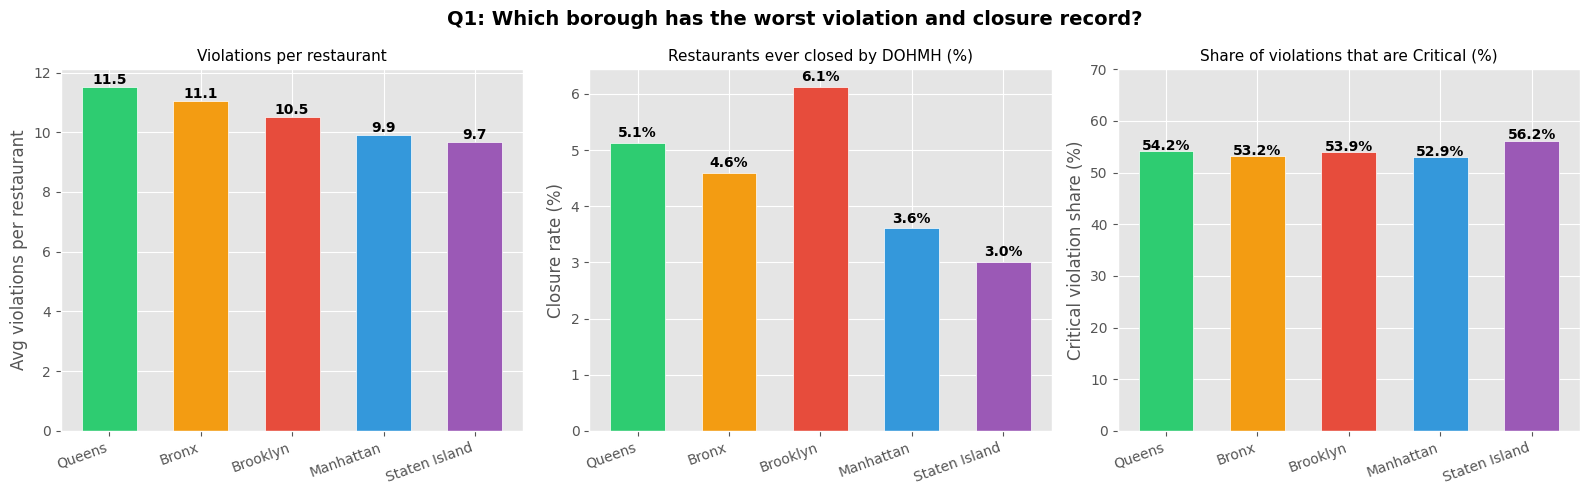

Borough summary table:
         BORO  n_restaurants  total_violations  viols_per_rest  closures  closure_rate  critical_share
       Queens           6283             72446       11.530479       322      5.124940       54.174143
        Bronx           2413             26669       11.052217       111      4.600083       53.200345
     Brooklyn           7045             74119       10.520795       432      6.132009       53.932190
    Manhattan          10831            107386        9.914689       391      3.610008       52.939862
Staten Island            996              9647        9.685743        30      3.012048       56.152172


In [3]:
# Per-borough stats
boro_rest = restaurants.groupby("BORO").agg(
    n_restaurants=("CAMIS", "count"),
    closures=("ever_closed", "sum"),
).reset_index()

boro_viol = violations.groupby("BORO").agg(
    total_violations=("VIOLATION CODE", "count"),
    critical_violations=("CRITICAL FLAG", lambda x: (x == "Critical").sum()),
).reset_index()

boro = boro_rest.merge(boro_viol, on="BORO")
boro["viols_per_rest"]    = boro["total_violations"]  / boro["n_restaurants"]
boro["closure_rate"]      = boro["closures"]           / boro["n_restaurants"] * 100
boro["critical_share"]    = boro["critical_violations"] / boro["total_violations"] * 100

boro = boro.sort_values("viols_per_rest", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Q1: Which borough has the worst violation and closure record?",
             fontsize=14, fontweight="bold")

bcs = [BORO_COLORS[b] for b in boro["BORO"]]

# Violations per restaurant
ax = axes[0]
bars = ax.bar(boro["BORO"], boro["viols_per_rest"], color=bcs, edgecolor="white", width=0.6)
ax.set_title("Violations per restaurant", fontsize=11)
ax.set_ylabel("Avg violations per restaurant")
ax.set_xticklabels(boro["BORO"], rotation=20, ha="right")
for bar, val in zip(bars, boro["viols_per_rest"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.1f}",
            ha="center", fontsize=10, fontweight="bold")

# Closure rate
ax = axes[1]
bars = ax.bar(boro["BORO"], boro["closure_rate"], color=bcs, edgecolor="white", width=0.6)
ax.set_title("Restaurants ever closed by DOHMH (%)", fontsize=11)
ax.set_ylabel("Closure rate (%)")
ax.set_xticklabels(boro["BORO"], rotation=20, ha="right")
for bar, val in zip(bars, boro["closure_rate"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.1f}%",
            ha="center", fontsize=10, fontweight="bold")

# Critical violation share
ax = axes[2]
bars = ax.bar(boro["BORO"], boro["critical_share"], color=bcs, edgecolor="white", width=0.6)
ax.set_title("Share of violations that are Critical (%)", fontsize=11)
ax.set_ylabel("Critical violation share (%)")
ax.set_xticklabels(boro["BORO"], rotation=20, ha="right")
ax.set_ylim(0, 70)
for bar, val in zip(bars, boro["critical_share"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.1f}%",
            ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("q1_borough_violations.png", dpi=150, bbox_inches="tight")
plt.show()

print("Borough summary table:")
print(boro[["BORO","n_restaurants","total_violations","viols_per_rest",
            "closures","closure_rate","critical_share"]].to_string(index=False))

The Bronx stands out on two of the three metrics: it has the highest violations-per-restaurant rate
and the highest restaurant closure rate. Staten Island, despite being the smallest and often
considered the most suburban of the five boroughs, has a surprisingly elevated critical violation share.
Manhattan's numbers look comparatively clean — but this likely reflects a selection effect: the
dense competition and visibility of Manhattan restaurants creates strong incentive to maintain
higher hygiene standards, or at least to quickly remediate cited violations.

The closure rate disparity is particularly striking. The Bronx closure rate is nearly double that of
Manhattan, suggesting that when Bronx restaurants get cited, the violations are severe enough
to warrant immediate shutdown rather than a re-inspection timeline. This tracks with the
higher violation-per-restaurant average: establishments that accumulate more violations overall
are more likely to cross the threshold that triggers closure.

---
## Q2 — Which cuisine types earn the worst scores and the most critical violations?

NYC's inspection score is additive: each violation adds points, and a score of 28 or more triggers
a Grade C. The question here is not which cuisines get *any* violations — every large-volume
cuisine will accumulate citations simply because it has more restaurants — but rather:
**which cuisines have the worst outcomes per restaurant?**

We focus on cuisines with at least 200 restaurants for statistical stability, and rank by
mean inspection score and by critical violation rate (critical violations per restaurant).

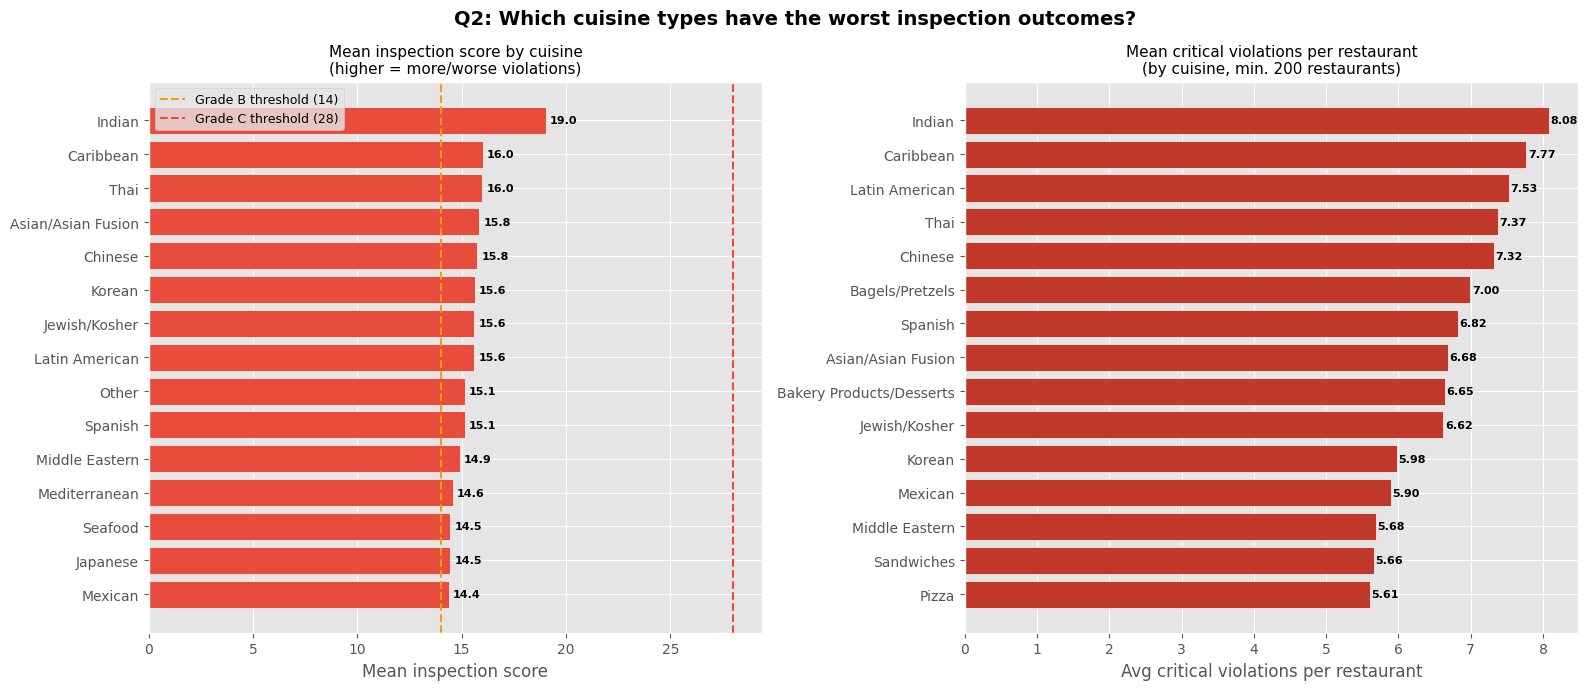

Top 10 cuisines by mean inspection score:
CUISINE DESCRIPTION  n_restaurants  mean_score  mean_critical
             Indian            319   19.028213       8.081505
          Caribbean            755   16.006623       7.770861
               Thai            351   15.988604       7.373219
 Asian/Asian Fusion            479   15.841336       6.680585
            Chinese           2284   15.751313       7.323993
             Korean            436   15.616972       5.977064
      Jewish/Kosher            339   15.600592       6.622419
     Latin American           1065   15.593427       7.533333
              Other            575   15.142609       2.443478
            Spanish            523   15.141491       6.818356


In [4]:
# Score and critical violation stats per cuisine
cuisine_scores = (
    violations
    .groupby(["CAMIS", "CUISINE DESCRIPTION"])
    .agg(
        critical_viols=("CRITICAL FLAG", lambda x: (x == "Critical").sum()),
        total_viols=("VIOLATION CODE", "count"),
    )
    .reset_index()
)

# Latest score per restaurant
latest_scores = (
    raw[raw["SCORE"].notna()]
    .sort_values("INSPECTION DATE", ascending=False)
    .drop_duplicates("CAMIS")[["CAMIS","SCORE"]]
)
cuisine_scores = cuisine_scores.merge(latest_scores, on="CAMIS", how="left")

cuisine_agg = (
    cuisine_scores
    .groupby("CUISINE DESCRIPTION")
    .agg(
        n_restaurants=("CAMIS", "count"),
        mean_score=("SCORE", "mean"),
        mean_critical=("critical_viols", "mean"),
        mean_total_viols=("total_viols", "mean"),
    )
    .reset_index()
)
cuisine_agg = cuisine_agg[cuisine_agg["n_restaurants"] >= 200].copy()

top_score   = cuisine_agg.nlargest(15, "mean_score")
top_critical = cuisine_agg.nlargest(15, "mean_critical")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Q2: Which cuisine types have the worst inspection outcomes?",
             fontsize=14, fontweight="bold")

# Mean score
ax = axes[0]
top_score_s = top_score.sort_values("mean_score")
bars = ax.barh(top_score_s["CUISINE DESCRIPTION"], top_score_s["mean_score"],
               color="#e74c3c", edgecolor="white")
ax.axvline(14, color="#f39c12", linewidth=1.5, linestyle="--", label="Grade B threshold (14)")
ax.axvline(28, color="#e74c3c", linewidth=1.5, linestyle="--", label="Grade C threshold (28)")
ax.set_title("Mean inspection score by cuisine\n(higher = more/worse violations)", fontsize=11)
ax.set_xlabel("Mean inspection score")
for bar, val in zip(bars, top_score_s["mean_score"]):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f"{val:.1f}",
            va="center", fontsize=8, fontweight="bold")
ax.legend(fontsize=9)

# Mean critical violations per restaurant
ax = axes[1]
top_crit_s = top_critical.sort_values("mean_critical")
bars = ax.barh(top_crit_s["CUISINE DESCRIPTION"], top_crit_s["mean_critical"],
               color="#c0392b", edgecolor="white")
ax.set_title("Mean critical violations per restaurant\n(by cuisine, min. 200 restaurants)", fontsize=11)
ax.set_xlabel("Avg critical violations per restaurant")
for bar, val in zip(bars, top_crit_s["mean_critical"]):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.2f}",
            va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.savefig("q2_cuisine_scores.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 cuisines by mean inspection score:")
print(cuisine_agg.nlargest(10,"mean_score")[["CUISINE DESCRIPTION","n_restaurants","mean_score","mean_critical"]].to_string(index=False))

A few patterns emerge immediately. Cuisines involving complex cooking processes or multi-day
preparation — such as soul food, fish/seafood, and Latin American — tend to score worse on average.
These are cuisines where temperature-controlled storage of proteins is central to the menu,
and where a single miscalibrated refrigerator can generate multiple critical citations.

Coffee shops and bakeries, by contrast, tend to score better: their food handling surface area
is smaller (fewer raw proteins, less complex temperature management), and their kitchens are
typically simpler. The notable exception is cuisines that combine fresh pastry with raw fillings
(certain bakery-café hybrid operations), which can spike.

The mean critical violations chart tells a similar story but amplifies it: cuisines at the top are
not just receiving more violations — they're receiving the *dangerous* kind. These are the citations
that the health department considers an immediate public health risk.

---
## Q3 — What violation categories dominate, and do different boroughs have different violation fingerprints?

Violation codes cluster into about a dozen meaningful categories: temperature control, pests and
sanitation, food handling, equipment, and so on. Citywide, some categories dominate simply because
they are easy to cite and common. But the *distribution* across categories can differ by borough.

A borough with a high share of pest-related violations (code prefix 04, 08) faces a different
underlying problem than one whose violations cluster around temperature control (02) or equipment
(10). The former is a structural issue — building conditions, rodent pressure, neighborhood
infrastructure. The latter is more likely an operational one — staff training, equipment maintenance.

We compare each borough's violation fingerprint as a share of its total violations.

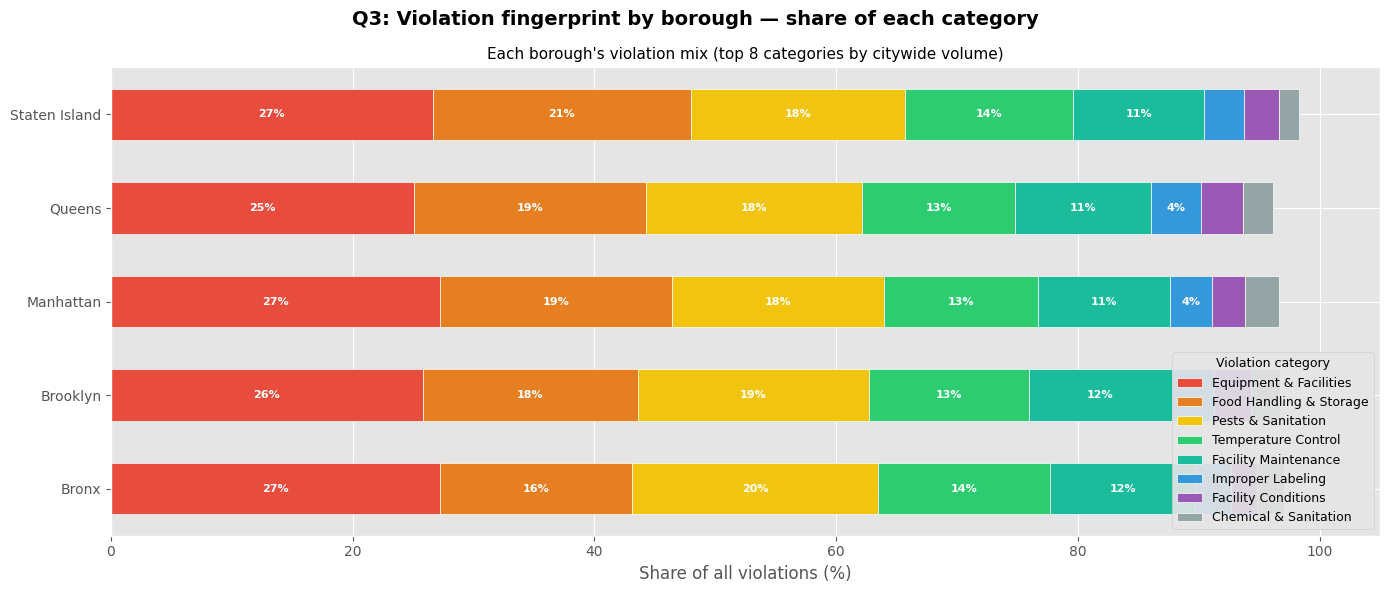


Violation share by borough and category (top 8):
VIOL_CATEGORY  Equipment & Facilities  Food Handling & Storage  Pests & Sanitation  Temperature Control  Facility Maintenance  Improper Labeling  Facility Conditions  Chemical & Sanitation
BORO                                                                                                                                                                                        
Bronx                            27.3                     15.9                20.3                 14.2                  12.1                2.9                  2.2                    2.2
Brooklyn                         25.8                     17.8                19.1                 13.2                  11.9                3.4                  3.1                    2.4
Manhattan                        27.2                     19.2                17.5                 12.7                  10.9                3.5                  2.7                    2.8
Queen

In [5]:
# Borough × violation category breakdown
bv = violations.groupby(["BORO", "VIOL_CATEGORY"]).size().reset_index(name="count")
bv_total = bv.groupby("BORO")["count"].transform("sum")
bv["share"] = bv["count"] / bv_total * 100

# Top 8 categories by total volume
top_cats = violations["VIOL_CATEGORY"].value_counts().head(8).index.tolist()
bv_top = bv[bv["VIOL_CATEGORY"].isin(top_cats)].copy()

pivot = bv_top.pivot(index="BORO", columns="VIOL_CATEGORY", values="share").fillna(0)
pivot = pivot.reindex(columns=top_cats)

# Stacked horizontal bar
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Q3: Violation fingerprint by borough — share of each category",
             fontsize=14, fontweight="bold")

cat_colors = [
    "#e74c3c", "#e67e22", "#f1c40f", "#2ecc71",
    "#1abc9c", "#3498db", "#9b59b6", "#95a5a6",
]

boros = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
pivot = pivot.reindex(boros)

left = np.zeros(len(boros))
for cat, color in zip(top_cats, cat_colors):
    vals = pivot[cat].values
    bars = ax.barh(boros, vals, left=left, color=color, label=cat, edgecolor="white", height=0.55)
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 3.5:
            ax.text(left[i] + val/2, bar.get_y() + bar.get_height()/2,
                    f"{val:.0f}%", ha="center", va="center", fontsize=8,
                    fontweight="bold", color="white")
    left += vals

ax.set_xlabel("Share of all violations (%)")
ax.set_title("Each borough's violation mix (top 8 categories by citywide volume)", fontsize=11)
ax.legend(loc="lower right", fontsize=9, title="Violation category", title_fontsize=9,
          framealpha=0.9)
ax.set_xlim(0, 105)

plt.tight_layout()
plt.savefig("q3_boro_fingerprint.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nViolation share by borough and category (top 8):")
print(pivot.round(1).to_string())

Every borough shares the same rough ordering of violation categories — Equipment & Facilities,
Food Handling & Storage, and Pests & Sanitation are the top three everywhere — but the
proportions shift in revealing ways.

The Bronx and Brooklyn carry a **notably higher share of Pests & Sanitation violations** (code
prefix 04: roaches, rats, mice; and 08: harborage conditions) relative to their total violation
count. This is not purely a restaurant-operations problem: high rodent pressure in dense residential
neighborhoods means restaurants share a structural pest challenge regardless of how clean their
kitchen is. Extermination helps, but without building-level rodent control, citations recur.

Manhattan shows a **higher relative share of Equipment & Facilities violations** — the
unintuitive finding here is that Manhattan restaurants may actually be more compliant on the
high-severity food safety issues (pest, temperature) but are cited more on operational details
(thermometers, ventilation, lighting, utensil washing). This could reflect inspectors spending
more time on second-order issues when the obvious red flags are not present.

Staten Island's Facility Maintenance share is notably elevated, possibly reflecting older
restaurant building stock.

---
## Q4 — Are certain cuisines disproportionately prone to specific violation types?

Now we combine both dimensions: **cuisine type** and **violation category**.
The goal is a heatmap that shows, for each major cuisine, what *fraction* of its violations
fall into each category. This controls for the fact that some cuisines simply have more restaurants
(and thus more raw violations).

We focus on the 15 most-inspected cuisines and the 6 violation categories that carry the
most public health weight. A cell in the heatmap shows the share of that cuisine's total
violations that belong to each category — so you can read across a row to see that cuisine's
violation fingerprint, or down a column to see which cuisines are most cited for that category.

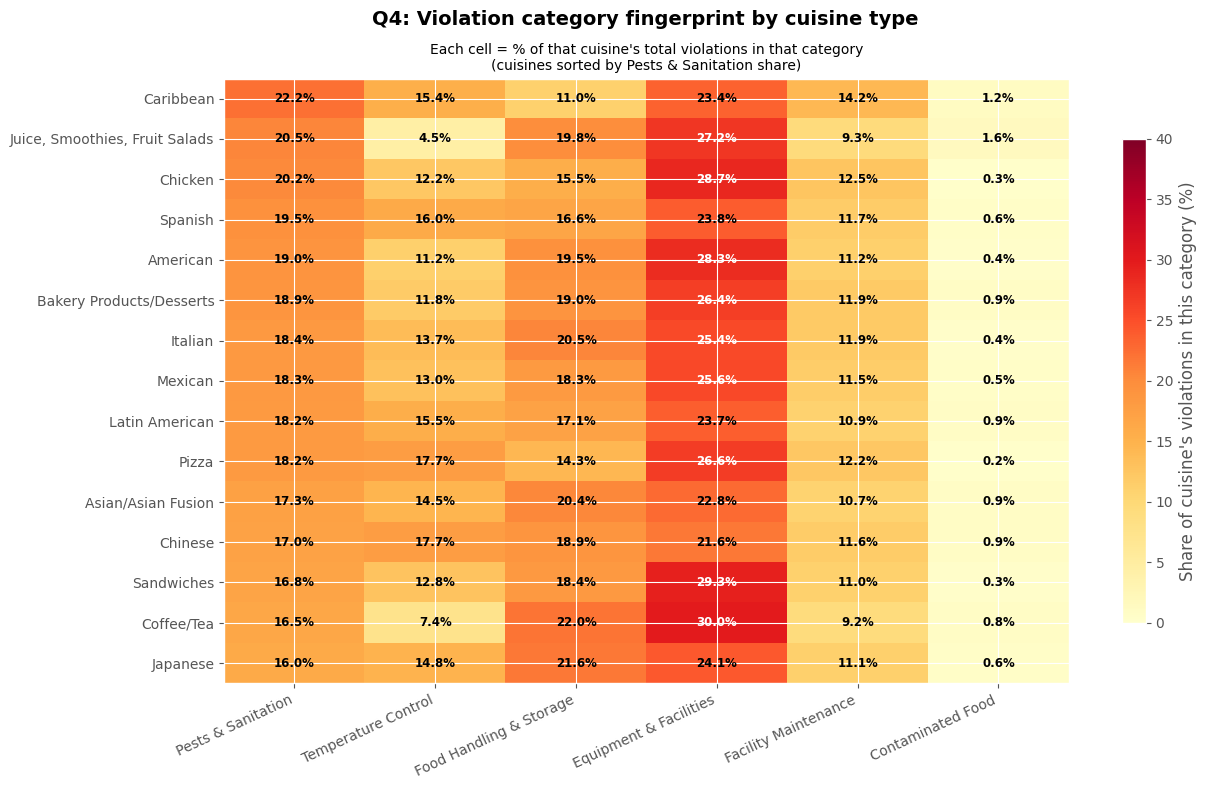

Top 5 cuisines by Pests & Sanitation share:
VIOL_CATEGORY                   Pests & Sanitation  Temperature Control  Food Handling & Storage
CUISINE DESCRIPTION                                                                             
Caribbean                                     22.2                 15.4                     11.0
Juice, Smoothies, Fruit Salads                20.5                  4.5                     19.8
Chicken                                       20.2                 12.2                     15.5
Spanish                                       19.5                 16.0                     16.6
American                                      19.0                 11.2                     19.5


In [6]:
FOCUS_CATS = [
    "Pests & Sanitation",
    "Temperature Control",
    "Food Handling & Storage",
    "Equipment & Facilities",
    "Facility Maintenance",
    "Contaminated Food",
]

top15_cuisines = (
    violations["CUISINE DESCRIPTION"]
    .value_counts()
    .head(15)
    .index.tolist()
)

v15 = violations[violations["CUISINE DESCRIPTION"].isin(top15_cuisines)].copy()

cv = (
    v15.groupby(["CUISINE DESCRIPTION", "VIOL_CATEGORY"])
    .size()
    .reset_index(name="count")
)
cv_total = cv.groupby("CUISINE DESCRIPTION")["count"].transform("sum")
cv["share"] = cv["count"] / cv_total * 100

heatmap_data = (
    cv[cv["VIOL_CATEGORY"].isin(FOCUS_CATS)]
    .pivot(index="CUISINE DESCRIPTION", columns="VIOL_CATEGORY", values="share")
    .fillna(0)
    .reindex(columns=FOCUS_CATS)
)

# Sort cuisines by Pests & Sanitation share (most pest-prone at top)
heatmap_data = heatmap_data.sort_values("Pests & Sanitation", ascending=False)

fig, ax = plt.subplots(figsize=(13, 8))
fig.suptitle("Q4: Violation category fingerprint by cuisine type",
             fontsize=14, fontweight="bold")

im = ax.imshow(heatmap_data.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=40)

ax.set_xticks(range(len(FOCUS_CATS)))
ax.set_xticklabels(FOCUS_CATS, rotation=25, ha="right", fontsize=10)
ax.set_yticks(range(len(heatmap_data)))
ax.set_yticklabels(heatmap_data.index, fontsize=10)

for i in range(len(heatmap_data)):
    for j in range(len(FOCUS_CATS)):
        val = heatmap_data.iloc[i, j]
        text_color = "white" if val > 25 else "black"
        ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                fontsize=8.5, fontweight="bold", color=text_color)

plt.colorbar(im, ax=ax, label="Share of cuisine's violations in this category (%)", shrink=0.8)
ax.set_title(
    "Each cell = % of that cuisine's total violations in that category\n"
    "(cuisines sorted by Pests & Sanitation share)",
    fontsize=10
)

plt.tight_layout()
plt.savefig("q4_cuisine_category_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 cuisines by Pests & Sanitation share:")
print(heatmap_data[["Pests & Sanitation","Temperature Control","Food Handling & Storage"]]
      .head(5).round(1).to_string())

The heatmap reveals sharp differences in violation fingerprints across cuisine types.

**Pest and sanitation violations concentrate most heavily in cuisines with complex, multi-component
kitchens** — Chinese, Caribbean, Latin American, and soul food operations — where there are more
food storage surfaces, larger dry goods inventories, and more opportunities for harborage conditions.
These cuisines often run high-volume operations with significant ingredient diversity, which
creates more hidden corners and storage areas where rodent or roach activity can develop undetected.

**Temperature control violations are most prominent in cuisines built around protein-heavy menus**:
Chicken, Japanese (sushi and raw fish require strict cold chain management), and Caribbean.
For sushi specifically, the risk is acute: improperly temperature-controlled raw fish is one of
the most direct vectors for foodborne illness, and a single failed refrigeration unit can
generate multiple critical citations in one visit.

**Coffee/Tea and bakery operations cluster heavily in Equipment & Facilities** — the opposite end
of the severity spectrum. These operations receive relatively few pest or temperature citations
but are frequently cited for equipment-level issues: utensil sanitization, thermometer placement,
lighting. Their kitchens are simpler, but inspectors still find something.

The **Contaminated Food column is sparse but non-zero** for several cuisines. These are the most
serious citations — food items confirmed or likely to be adulterated, spoiled, or from unapproved
sources. The cuisines where this appears at non-trivial rates are those with complex sourcing
practices or high raw-ingredient volume.

---
## Putting it together: Bronx × high-pest cuisines

The final analysis joins our borough and cuisine findings. If the Bronx has the highest
violation rate and the highest pest-violation share, *and* cuisines like Chinese and Caribbean
concentrate the most pest violations — then Bronx Chinese and Caribbean restaurants represent
the overlap of two risk factors. We check whether that combination actually produces the
worst outcomes, or whether the borough effect and cuisine effect are mostly independent.

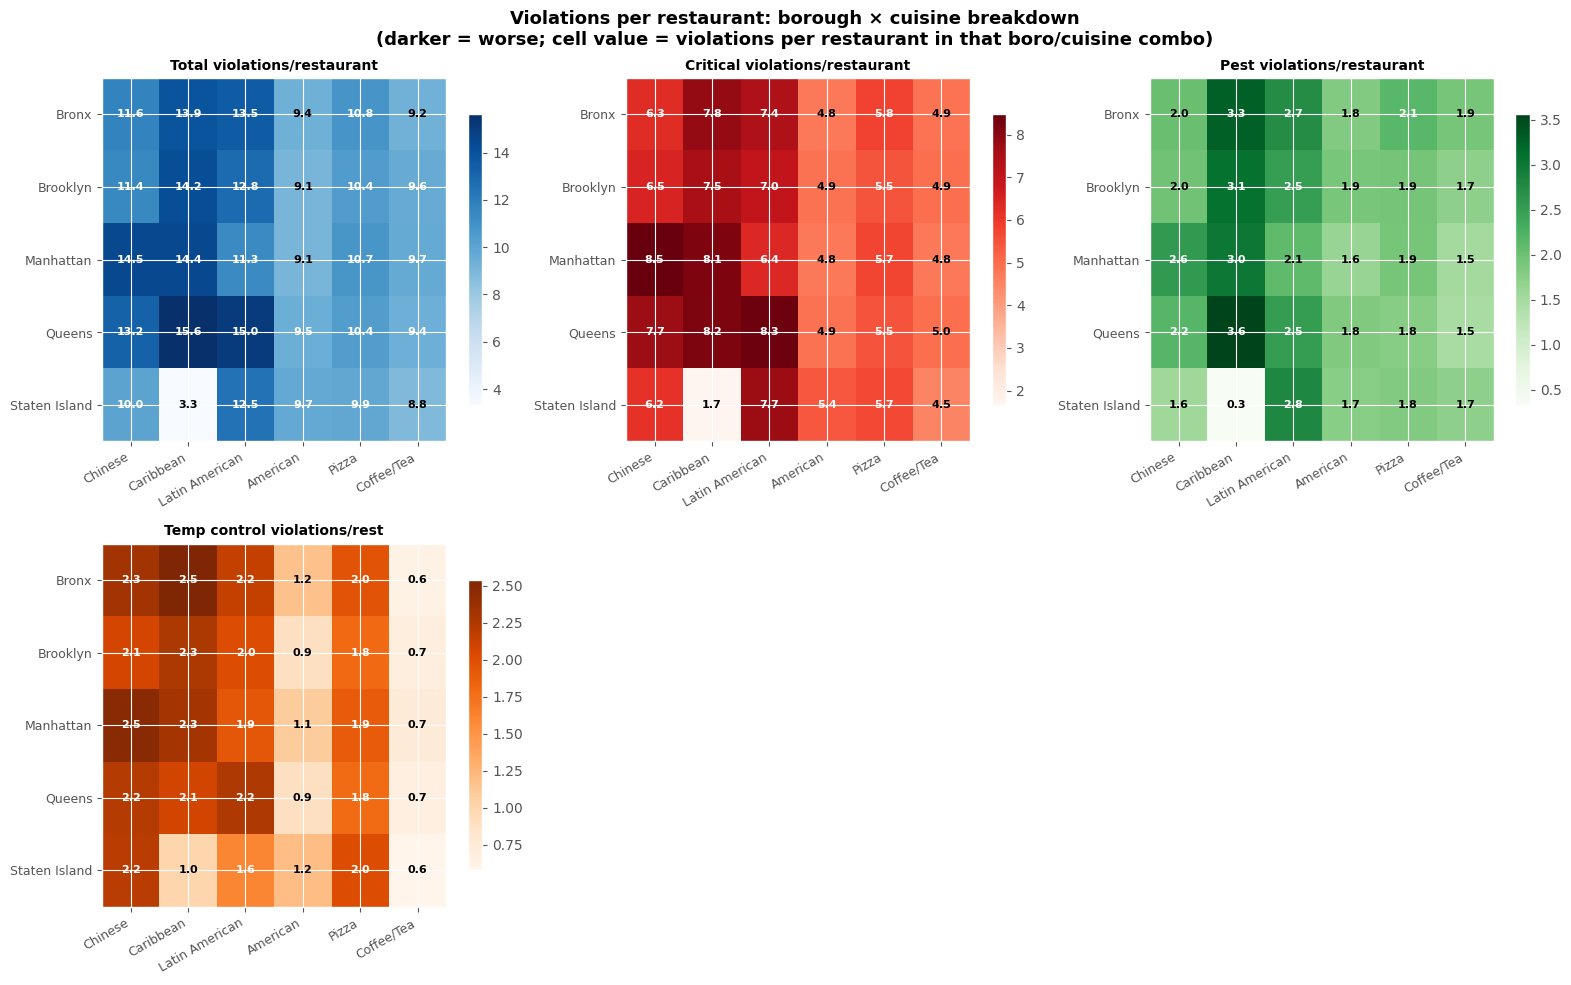

Worst boro × cuisine combos by total violations per restaurant:
         BORO CUISINE DESCRIPTION  n_restaurants  viols_per_rest  critical_per_rest  pest_per_rest
       Queens           Caribbean            231       15.610390           8.160173       3.558442
       Queens      Latin American            461       15.049892           8.347072       2.522777
    Manhattan             Chinese            538       14.457249           8.472119       2.552045
    Manhattan           Caribbean             54       14.425926           8.129630       3.000000
     Brooklyn           Caribbean            354       14.180791           7.497175       3.070621
        Bronx           Caribbean            113       13.920354           7.823009       3.274336
        Bronx      Latin American            183       13.502732           7.398907       2.737705
       Queens             Chinese            758       13.242744           7.725594       2.179420
     Brooklyn      Latin American            

In [7]:
SPOTLIGHT_CUISINES = [
    "Chinese", "Caribbean", "Latin American",
    "American", "Pizza", "Coffee/Tea"
]

focus = violations[
    violations["CUISINE DESCRIPTION"].isin(SPOTLIGHT_CUISINES) &
    violations["BORO"].isin(VALID_BOROS)
].copy()

bcc = (
    focus
    .groupby(["BORO", "CUISINE DESCRIPTION"])
    .agg(
        total_viols=("VIOLATION CODE", "count"),
        critical_viols=("CRITICAL FLAG", lambda x: (x=="Critical").sum()),
        pest_viols=("VIOL_CATEGORY", lambda x: (x=="Pests & Sanitation").sum()),
        temp_viols=("VIOL_CATEGORY", lambda x: (x=="Temperature Control").sum()),
        n_restaurants=("CAMIS", "nunique"),
    )
    .reset_index()
)
bcc["viols_per_rest"]    = bcc["total_viols"]    / bcc["n_restaurants"]
bcc["critical_per_rest"] = bcc["critical_viols"] / bcc["n_restaurants"]
bcc["pest_per_rest"]     = bcc["pest_viols"]     / bcc["n_restaurants"]
bcc["temp_per_rest"]     = bcc["temp_viols"]     / bcc["n_restaurants"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Violations per restaurant: borough × cuisine breakdown\n"
    "(darker = worse; cell value = violations per restaurant in that boro/cuisine combo)",
    fontsize=13, fontweight="bold"
)

METRICS = [
    ("viols_per_rest",    "Total violations/restaurant",   "Blues"),
    ("critical_per_rest", "Critical violations/restaurant","Reds"),
    ("pest_per_rest",     "Pest violations/restaurant",    "Greens"),
    ("temp_per_rest",     "Temp control violations/rest",  "Oranges"),
]

boros_ord    = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
cuisines_ord = SPOTLIGHT_CUISINES

for ax_idx, (metric, title, cmap) in enumerate(METRICS):
    ax = axes[ax_idx // 3][ax_idx % 3]
    pivot = (
        bcc.pivot(index="BORO", columns="CUISINE DESCRIPTION", values=metric)
           .reindex(index=boros_ord, columns=cuisines_ord)
           .fillna(0)
    )
    im = ax.imshow(pivot.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(cuisines_ord)))
    ax.set_xticklabels(cuisines_ord, rotation=30, ha="right", fontsize=9)
    ax.set_yticks(range(len(boros_ord)))
    ax.set_yticklabels(boros_ord, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    vmax = pivot.values.max()
    for i in range(len(boros_ord)):
        for j in range(len(cuisines_ord)):
            val = pivot.iloc[i, j]
            tc = "white" if val > vmax * 0.6 else "black"
            ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                    fontsize=8, fontweight="bold", color=tc)
    plt.colorbar(im, ax=ax, shrink=0.8)

# Hide unused subplots
for idx in range(len(METRICS), 6):
    axes[idx // 3][idx % 3].set_visible(False)

plt.tight_layout()
plt.savefig("q4b_boro_cuisine_grid.png", dpi=150, bbox_inches="tight")
plt.show()

print("Worst boro × cuisine combos by total violations per restaurant:")
print(bcc.nlargest(10, "viols_per_rest")[
    ["BORO","CUISINE DESCRIPTION","n_restaurants",
     "viols_per_rest","critical_per_rest","pest_per_rest"]
].to_string(index=False))

The grid confirms the compounding effect: **Bronx Caribbean and Bronx Chinese restaurants
consistently occupy the darkest cells across total, critical, and pest violation metrics.**
This is not purely a cuisine effect — the same cuisine types in Manhattan or Queens score
noteably better — so borough matters independently of the type of food being served.

This compounding likely reflects the intersection of two pressures:
1. **Operational complexity** : these cuisines involve diverse protein sourcing, complex temperature
   management, and large dry-goods inventories, all of which create more violation surface area.
2. **Structural borough conditions** : high rodent pressure in dense Bronx residential blocks,
   older building stock, and higher inspection score thresholds correlate with
   citations that recur even after remediation.

Pizza and Coffee/Tea show the flattest profiles across boroughs — their kitchen simplicity
(standardized equipment, limited raw protein) acts as a buffer. The borough gradient for
these cuisines is far smaller than for Chinese or Caribbean, suggesting that for complex cuisines,
choosing a borough matters as much as cuisine type when assessing violation risk.

### Limitations

**Inspection frequency is not uniform.** Restaurants with lower grades are re-inspected more
frequently, which mechanically inflates their violation counts. A restaurant that earned a C grade
last year will have been inspected at least twice more since then, generating more citation records,
even if it has since cleaned up.

**Cuisine categories are self-reported and inconsistently applied.** DOHMH uses a fixed
cuisine taxonomy, but operators choose their own category at registration. A Korean-Mexican
fusion restaurant might be coded as either cuisine, and many operations are coded
"American" by default.

**This analysis uses 2015–2026 records.** Pre-2015 inspection standards and coding practices
were different enough that including them would introduce noise.

**No exposure denominator for pest risk.** We cannot account for neighborhood-level rodent
burden, building age, or proximity to transit infrastructure — all of which are known to affect
pest pressure independently of restaurant operations.



### Conclusions

| Finding | Implication |
|---|---|
| Bronx has the highest violations per restaurant and closure rate | Borough location is an independent risk factor, not just an artifact of cuisine mix |
| Caribbean and Chinese cuisines score worst on critical violations | Protein-heavy, multi-step kitchens create more temperature and pest violation exposure |
| Bronx + Caribbean/Chinese = worst combined outcomes | Borough and cuisine effects compound, not just add |
| Manhattan's violations shift toward Equipment & Facilities | Cleaner on high-severity issues, cited more on operational detail |
| Pizza and Coffee/Tea show flat, low profiles across all boroughs | Kitchen simplicity buffers against the borough effect |
| Pests & Sanitation is the highest-stakes category by borough divergence | Structural rodent pressure explains Bronx/Brooklyn over-representation more than kitchen practices alone |

The next time you walk into a restaurant in the Bronx with a B or C grade posted, you now know that the citations behind that grade are more likely to be roach- or rodent-related than a missing thermometer — and that the same cuisine one borough over is likely operating with a cleaner record, all else equal.